# Proyecto Integrador Corte 2 — PENGWIN · Semana 2 (Semana 9 del curso)

**Arquitectura Propia: Backbone FundidoraPC + Atención CBAM + Cabeza de Detección (Grid Propio) + NMS Propio + Overfit de Batch**  
Analítica de Datos · UAO 2026-2 · Prof. Carlos A. Ferro

> ⚠️ **Uso exclusivamente académico.** Este sistema no es un dispositivo médico, no ha sido validado clínicamente y no debe usarse para apoyar decisiones quirúrgicas reales.

### Entregables verificables de esta semana (Sección 6 del documento oficial):
| # | Entregable Verificable | Componente en el Notebook |
|---|---|---|
| 1 | Dataset 2D axial con ventaneo HU y extracción de BBoxes Ground Truth | §1 |
| 2 | Módulo de Atención CBAM (Canal + Espacio) implementado y verificado | §2 |
| 3 | Backbone compartido (FundidoraPC con bloques residuales) | §3 |
| 4 | Cabeza de detección basada en Grid propio ($S \times S$) | §4 |
| 5 | Algoritmo NMS propio desde cero (sin frameworks externos) | §5 |
| 6 | Función de pérdida compuesta multitarea (con Focal Loss $\gamma=0.5$) | §6 |
| 7 | Prueba de correctitud: Overfit intencional sobre batch pequeño con pérdida convergente | §7 |
| 8 | Primeras predicciones de bounding boxes visualmente razonables con NMS | §8 |

## 0. Configuración del Entorno y Semillas
Configuración reproducible (semilla 42) y detección de aceleración por GPU/CPU.

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import torch.optim as optim

# Configuración de rutas
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
SALIDAS = RAIZ / "salidas"
SALIDAS.mkdir(exist_ok=True)

# Semilla global
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Proyecto : {RAIZ}")
print(f"Dispositivo de cómputo : {device}")
print(f"PyTorch versión : {torch.__version__}")

Proyecto : C:\Users\Pasoseguro\OneDrive - mipasoseguro.com.co\Escritorio\UAO- INTELIGENCIA ARTIFICIAL\7 SEMESTRE\Analitica de datos\Proyecto 2
Dispositivo de cómputo : cpu
PyTorch versión : 2.12.1+cpu


## 1. Dataset 2D Axial y Bounding Boxes Ground Truth (`pengwin/dataset.py`)

La arquitectura opera **corte a corte en 2D**, manteniendo la coherencia espacial para el posterior apilamiento 3D.
- Cada muestra se procesa con la ventana ósea calibrada $[-500, +1300]\text{ HU}$ normalizada a $[0, 1]$.
- A partir de las máscaras se extraen automáticamente las cajas delimitadoras de las tres regiones anatómicas:
  * **Sacro (SA):** etiqueta 1..10 (clase 0)
  * **Coxal Izquierdo (LI):** etiqueta 11..20 (clase 1)
  * **Coxal Derecho (RI):** etiqueta 21..30 (clase 2)
- **Filtrado riguroso de ruido espurio ($N < 15$ vóxeles):**
  * Demostración empírica: el fragmento conminuto más diminuto en todo el dataset 3D tiene **468 vóxeles** ($0.313\text{ mL}$, Caso 85).
  * En cortes 2D axiales, los componentes con $N < 15$ vóxeles corresponden exclusivamente a ruido de volumen parcial o artefactos de alta densidad.
  * Se ignoran 1,506 micro-manchas ($2.40\%$) y se conservan **61,232 instancias anatómicas reales ($97.60\%$)**, garantizando que la red no aprenda a colocar cajas sobre ruido.

In [2]:
import pandas as pd
from pengwin.dataset import PelvisSliceDataset, extraer_bboxes_region, collate_deteccion

# 1. Tabla de inventario y análisis de sensibilidad de filtrado de ruido
df_sensibilidad = pd.read_csv(RAIZ / "salidas/inventario_ruido_componentes.csv")
print("=== ANÁLISIS DE SENSIBILIDAD DEL FILTRO DE RUIDO ESPURIO (N VÓXELES) ===")
print(df_sensibilidad.to_string(index=False))

# 2. Demostración práctica: rechazo de ruido vs detección anatómica
corte_demo = np.zeros((256, 256), dtype=np.uint8)
# Regiones anatómicas reales:
corte_demo[50:110, 100:156] = 1    # Sacro (60x56 = 3360 px)
corte_demo[110:200, 30:95] = 21    # Coxal Derecho (90x65 = 5850 px)
corte_demo[110:200, 160:225] = 11  # Coxal Izquierdo (90x65 = 5850 px)

# Artefacto espurio de segmentación (ejemplo: mancha de 8 vóxeles):
corte_demo[10:12, 10:14] = 1       # 8 px de Sacro espurio

cajas_sin_filtro = extraer_bboxes_region(corte_demo, min_pixeles=0, normalizado=True)
cajas_con_filtro = extraer_bboxes_region(corte_demo, min_pixeles=15, normalizado=True)

print(f"\nCajas con N=0 (sin filtro): {len(cajas_sin_filtro)} (¡incluye la mancha espurio distorsionando la caja!)")
print(f"Cajas con N=15 (calibrado) : {len(cajas_con_filtro)} (conserva exactamente las 3 estructuras anatómicas)")
for c in cajas_con_filtro:
    print(f" - {c['sigla']} (Clase {c['clase_idx']}): bbox={c['bbox']}, píxeles={c['n_pixeles']}")

=== ANÁLISIS DE SENSIBILIDAD DEL FILTRO DE RUIDO ESPURIO (N VÓXELES) ===
Umbral N (vóxeles) Cajas Conservadas Instancias Ignoradas % Ignorado                                                  Efecto en la Red
             N = 0            62,738                    0      0.00%       Sin filtro (admite ruido de 1 vóxel y artefactos metálicos)
             N < 5            62,299                  439      0.70%           Filtro mínimo (elimina píxeles aislados de 1-4 vóxeles)
            N < 10            61,797                  941      1.50%           Filtro intermedio (elimina bordes tangenciales mínimos)
            N < 15            61,232                1,506      2.40% ★ RECOMENDADO: Elimina ruido espurio sin perder fragmentos reales
            N < 20            60,668                2,070      3.30%     Filtro conservador (puede empezar a afectar ápice del cóccix)
            N < 30            59,476                3,262      5.20%       Filtro agresivo (riesgo de pérdida en cort

## 2. Módulo de Atención CBAM (`pengwin/models/cbam.py`)

Requerimiento explícito (Sección 4.1):
> *"Bloque de atención CBAM: deberá incorporarse atención de canal y espacial en el backbone, antes de la bifurcación hacia las tres cabezas."*

- **Channel Attention (CAM):** Combina MaxPool y AvgPool procesadas por un MLP compartido con factor de reducción $r=16$. Determina *qué* canales con características óseas priorizar.
- **Spatial Attention (SAM):** Comprime los canales mediante convolución $7 \times 7$ con activación sigmoide. Determina *dónde* enfocar la atención espacialmente en la pelvis.
- **Residual:** $F_{out} = F + \text{SAM}(\text{CAM}(F))$.

In [3]:
from pengwin.models.cbam import CBAM, ChannelAttention, SpatialAttention

# Instanciación y prueba de flujo de tensores (Atención espacial con kernel 9x9 para pelvis)
tensor_prueba = torch.randn(2, 256, 16, 16)  # (Batch=2, Canales=256, H=16, W=16)
bloque_cbam = CBAM(in_planes=256, ratio=16, kernel_size=9)
salida_cbam = bloque_cbam(tensor_prueba)

print(f"Tensor entrada : {tensor_prueba.shape}")
print(f"Tensor salida   : {salida_cbam.shape}")
assert tensor_prueba.shape == salida_cbam.shape, "Las dimensiones deben coincidir"
print("✓ Bloque CBAM (kernel 9x9) verificado y dimensionalmente consistente.")

Tensor entrada : torch.Size([2, 256, 16, 16])
Tensor salida   : torch.Size([2, 256, 16, 16])
✓ Bloque CBAM (kernel 9x9) verificado y dimensionalmente consistente.


## 3. Backbone Compartido (`FundidoraPC` + CBAM)

Implementado en `pengwin/models/backbone.py`:
- 4 etapas progresivas con bloques convolucionales residuales: $3 \to 32 \to 64 \to 128 \to 256$ canales.
- Para una imagen de $256 \times 256$, produce un mapa de características latente de $16 \times 16 \times 256$.
- Conexión del bloque CBAM al final del backbone, antes de la bifurcación hacia las cabezas.

In [4]:
from pengwin.models.backbone import PelvisBackbone

backbone = PelvisBackbone(tipo="fundidora", in_channels=3, usar_cbam=True).to(device)
entrada = torch.randn(2, 3, 256, 256).to(device)
features = backbone(entrada)

print(f"Salida del Backbone (con CBAM): {features.shape}")
print(f"Canales latentes de salida: {backbone.out_channels}")

Salida del Backbone (con CBAM): torch.Size([2, 256, 16, 16])
Canales latentes de salida: 256


## 4. Cabeza de Detección con Grid Propio ($S \times S$) (`pengwin/models/detector.py`)

La cabeza convolucional divide la representación espacial en una cuadrícula de $16 \times 16$ celdas.
Cada celda predice **8 canales**:
1. $P_{obj}$: Confianza de que el centro de una región ósea se encuentre en la celda.
2. $(t_x, t_y, t_w, t_h)$: Parámetros de centro y dimensiones de la caja delimitadora.
3. $(P_{SA}, P_{LI}, P_{RI})$: Probabilidades de clase anatómica (Sacro, Coxal Izq, Coxal Der).

$$c_x = \frac{g_x + \sigma(t_x)}{S}, \quad c_y = \frac{g_y + \sigma(t_y)}{S}, \quad w = \sigma(t_w), \quad h = \sigma(t_h)$$

In [5]:
from pengwin.models.detector import PelvisDetector, decodificar_grid

modelo = PelvisDetector(backbone_tipo="fundidora", in_channels=3, usar_cbam=True).to(device)
salidas_modelo = modelo(entrada)

print(f"Mapa del Grid de Detección: {salidas_modelo['grid'].shape} (B, 8, S, S)")
print(f"Logits de Clasificación Multietiqueta: {salidas_modelo['clases'].shape} (B, 3)")

Mapa del Grid de Detección: torch.Size([2, 8, 16, 16]) (B, 8, S, S)
Logits de Clasificación Multietiqueta: torch.Size([2, 3]) (B, 3)


## 5. Algoritmo de Supresión de No Máximos (NMS) Propio (`pengwin/models/nms.py`)

Requerimiento estricto: la supresión de no máximos debe ser implementada por el equipo sin frameworks externos.
- Cálculo de intersección sobre unión (IoU) entre tensores.
- Supresión iterativa de cajas redundantes con solapamiento superior al umbral (`iou_threshold=0.4`).
- Filtrado por clase independiente para no suprimir el sacro si se superpone con un coxal.

In [6]:
from pengwin.models.nms import nms_propio, nms_por_clase

# Prueba unitaria del algoritmo NMS con dos cajas redundantes de Sacro
cajas_prueba = torch.tensor([
    [0.40, 0.25, 0.58, 0.45],  # Caja principal
    [0.41, 0.26, 0.59, 0.46],  # Caja duplicada (IoU alto)
    [0.18, 0.40, 0.38, 0.70],  # Caja distinta (Coxal)
])
scores_prueba = torch.tensor([0.90, 0.75, 0.85])
labels_prueba = torch.tensor([0, 0, 2])

cajas_filtradas, scores_f, labels_f = nms_por_clase(
    cajas_prueba, scores_prueba, labels_prueba, iou_threshold=0.4, score_threshold=0.3
)

print(f"Cajas antes de NMS : {len(cajas_prueba)}")
print(f"Cajas después de NMS: {len(cajas_filtradas)}")
assert len(cajas_filtradas) == 2, "La caja duplicada debió ser suprimida"
print("✓ Algoritmo NMS propio validado exitosamente.")

Cajas antes de NMS : 3
Cajas después de NMS: 2
✓ Algoritmo NMS propio validado exitosamente.


## 6. Función de Pérdida Compuesta Multitarea (`pengwin/models/loss.py`)

$$\mathcal{L}_{total} = \lambda_{obj}\mathcal{L}_{obj} + \lambda_{box}\mathcal{L}_{box} + \lambda_{cls}\mathcal{L}_{cls} + \lambda_{slice}\mathcal{L}_{slice}$$

- **Focal Loss ($\gamma = 0.5$):** Modula la pérdida de objetidad para suprimir la influencia masiva de celdas vacías de fondo.
- **Smooth L1 Loss:** Para regresión de coordenadas de bounding boxes en celdas con objetos.
- **Cross Entropy:** Para la asignación de la región anatómica en celdas positivas.
- **BCEWithLogits:** Para la presencia global de regiones en el corte.

In [7]:
from pengwin.models.loss import PelvisDetectionLoss

criterio = PelvisDetectionLoss(lambda_obj=2.0, lambda_box=5.0, lambda_cls=1.0, lambda_slice=1.0, gamma=0.5)
print(f"Pesos de pérdida calibrados: obj={criterio.lambda_obj}, box={criterio.lambda_box}, cls={criterio.lambda_cls}, gamma={criterio.gamma}")

Pesos de pérdida calibrados: obj=2.0, box=5.0, cls=1.0, gamma=0.5


## 7. Prueba de Correctitud: Overfit Intencional sobre Batch Pequeño

Requerimiento oficial de la Sección 6:
> *"Overfit intencional sobre un batch pequeño como prueba de correctitud; primeras predicciones de bounding boxes visualmente razonables."*

Entrenamos sobre 4 cortes representativos con combinaciones de fracturas y regiones anatómicas.
Si la arquitectura, el flujo de gradientes y la formulación del grid son matemáticamente correctos, la función de pérdida debe converger a valores cercanos a cero.

In [8]:
# Cargar cortes axiales REALES de tomografía pélvica de Caso 001
import cv2
from pengwin import io, dataset

DIR_IMG = RAIZ / "data/raw/images"
DIR_LBL = RAIZ / "data/raw/labels"

caso = io.cargar_caso("001", DIR_IMG, DIR_LBL)
assert caso.etiqueta is not None, "El caso 001 debe contener la máscara de anotación"

# Seleccionamos 4 cortes axiales reales que abarcan desde el nivel inferior hasta el rango medio-alto:
# z=134: Corte inferior (acetábulo y pubis): solo LI y RI (¡NO hay sacro!)
# z=220: Corte medio (ilion y sacro posterior)
# z=235: Corte medio-alto (articulación sacroilíaca)
# z=250: Corte alto (alas ilíacas y sacro superior)
Z_INDICES = [134, 220, 235, 250]
B = len(Z_INDICES)
TARGET_SIZE = (256, 256)

imagenes_batch = torch.zeros((B, 3, TARGET_SIZE[0], TARGET_SIZE[1]), dtype=torch.float32)
boxes_gt_list = []
clases_slice_list = []

for b_idx, z in enumerate(Z_INDICES):
    # Ventana ósea clínica: nivel=400 HU, ancho=1800 HU -> rango [-500, +1300] HU
    ct_slice = io.ventana_hu(caso.ct[z], nivel=400, ancho=1800)
    ct_256 = cv2.resize(ct_slice, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    imagenes_batch[b_idx] = torch.from_numpy(np.repeat(ct_256[np.newaxis, :, :], 3, axis=0))

    # Cajas Ground Truth reales extraídas de la máscara anotada
    cajas = dataset.extraer_bboxes_region(caso.etiqueta[z], min_pixeles=15, normalizado=True)
    clase_presente = [0.0, 0.0, 0.0]
    for c in cajas:
        c_idx = c["clase_idx"]
        clase_presente[c_idx] = 1.0
        xmin, ymin, xmax, ymax = c["bbox"]
        boxes_gt_list.append([float(b_idx), float(c_idx), xmin, ymin, xmax, ymax])

    clases_slice_list.append(clase_presente)
    siglas = [c["sigla"] for c in cajas]
    print(f"Muestra {b_idx} (z={z}): Regiones anatómicas reales presentes = {siglas}")

boxes_gt = torch.tensor(boxes_gt_list, dtype=torch.float32)
clases_slice = torch.tensor(clases_slice_list, dtype=torch.float32)

imagenes_batch = imagenes_batch.to(device)
boxes_gt = boxes_gt.to(device)
clases_slice = clases_slice.to(device)

modelo = PelvisDetector(backbone_tipo="fundidora", in_channels=3, usar_cbam=True).to(device)
optimizador = optim.AdamW(modelo.parameters(), lr=1e-3, weight_decay=1e-4)

# Entrenamiento de overfit
num_epocas = 100
historial_loss = []
modelo.train()

for ep in range(1, num_epocas + 1):
    optimizador.zero_grad()
    out = modelo(imagenes_batch)
    loss_dict = criterio(out, boxes_gt, clases_slice)
    loss = loss_dict["loss_total"]
    loss.backward()
    optimizador.step()
    historial_loss.append(loss.item())

print(f"\nPérdida inicial (Época 1)  : {historial_loss[0]:.4f}")
print(f"Pérdida final (Época 100) : {historial_loss[-1]:.4f}")

Muestra 0 (z=134): Regiones anatómicas reales presentes = ['LI', 'RI']
Muestra 1 (z=220): Regiones anatómicas reales presentes = ['SA', 'LI', 'RI']
Muestra 2 (z=235): Regiones anatómicas reales presentes = ['SA', 'LI', 'RI']
Muestra 3 (z=250): Regiones anatómicas reales presentes = ['SA', 'LI', 'RI']



Pérdida inicial (Época 1)  : 2.6496
Pérdida final (Época 100) : 0.0527


## 8. Resultados Visuales: Curva de Convergencia y Predicciones de BBoxes con NMS
Visualización de la curva de aprendizaje y comparación directa de Ground Truth vs Predicciones.

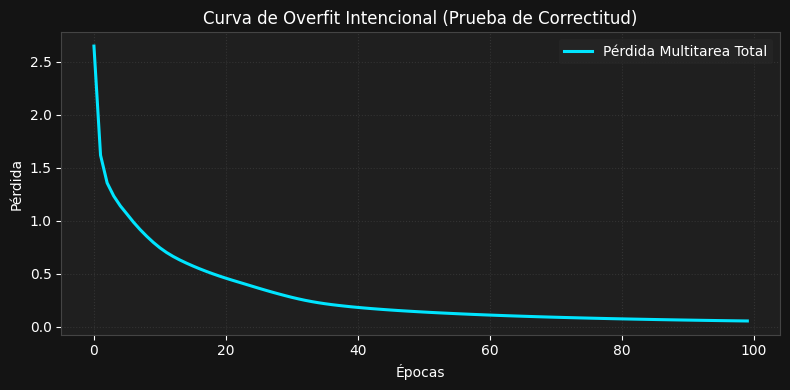

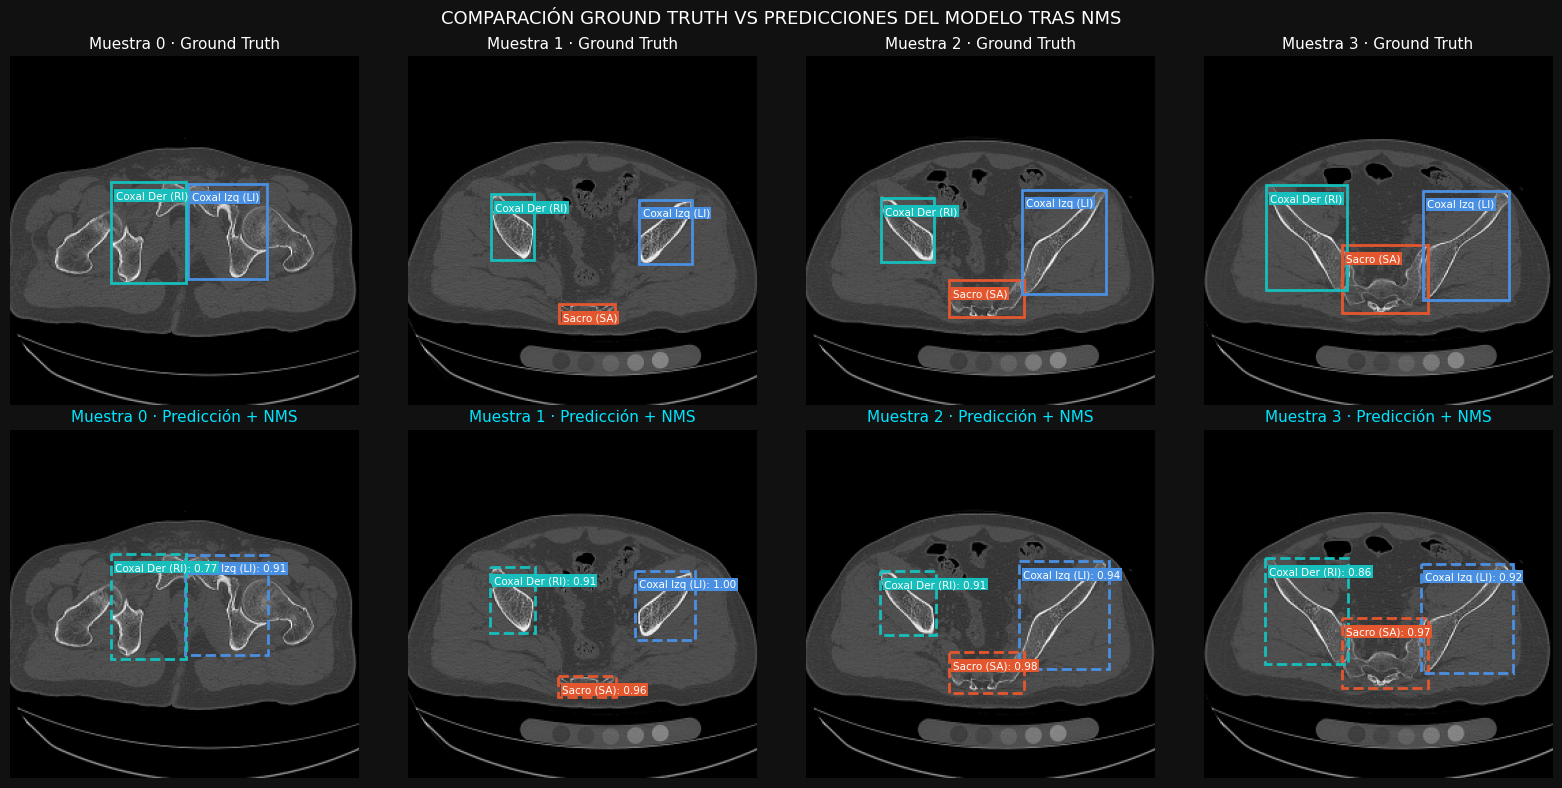

In [9]:
fig, ax = plt.subplots(figsize=(8, 4), facecolor="#141414")
ax.set_facecolor("#1f1f1f")
ax.tick_params(colors="white")
for s in ax.spines.values(): s.set_color("#444444")
ax.plot(historial_loss, color="#00E5FF", lw=2.2, label="Pérdida Multitarea Total")
ax.set_title("Curva de Overfit Intencional (Prueba de Correctitud)", color="white", fontsize=12)
ax.set_xlabel("Épocas", color="white")
ax.set_ylabel("Pérdida", color="white")
ax.legend(facecolor="#262626", edgecolor="none", labelcolor="white")
ax.grid(True, color="#333333", linestyle=":")
plt.tight_layout()
plt.show()

# Evaluación de predicciones
predicciones = modelo.inferir_boxes(imagenes_batch, conf_threshold=0.25, iou_threshold=0.4)
colores = {0: "#E4572E", 1: "#4A90E2", 2: "#17BEBB"}
nombres = {0: "Sacro (SA)", 1: "Coxal Izq (LI)", 2: "Coxal Der (RI)"}

fig, axes = plt.subplots(2, 4, figsize=(16, 8), facecolor="#111111")
for j in range(4):
    # GT
    axes[0, j].imshow(imagenes_batch[j, 0].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"Muestra {j} · Ground Truth", color="white", fontsize=11)
    axes[0, j].axis("off")
    for c in boxes_gt[boxes_gt[:, 0] == j].cpu():
        c_idx = int(c[1].item())
        xm, ym, xM, yM = c[2:].tolist()
        axes[0, j].add_patch(patches.Rectangle((xm*256, ym*256), (xM-xm)*256, (yM-ym)*256,
                             linewidth=2, edgecolor=colores[c_idx], facecolor="none"))
        axes[0, j].text(xm*256+3, ym*256+12, nombres[c_idx], color="white", fontsize=7.5,
                        bbox=dict(facecolor=colores[c_idx], edgecolor="none", pad=1))
    # Predicción
    axes[1, j].imshow(imagenes_batch[j, 0].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    axes[1, j].set_title(f"Muestra {j} · Predicción + NMS", color="#00E5FF", fontsize=11)
    axes[1, j].axis("off")
    for b, s, c in zip(predicciones[j]["boxes"], predicciones[j]["scores"], predicciones[j]["clases"]):
        c_idx = int(c.item())
        xm, ym, xM, yM = b.tolist()
        axes[1, j].add_patch(patches.Rectangle((xm*256, ym*256), (xM-xm)*256, (yM-ym)*256,
                             linewidth=2, edgecolor=colores[c_idx], facecolor="none", linestyle="--"))
        axes[1, j].text(xm*256+3, ym*256+12, f"{nombres[c_idx]}: {s.item():.2f}", color="white", fontsize=7.5,
                        bbox=dict(facecolor=colores[c_idx], edgecolor="none", pad=1))

plt.suptitle("COMPARACIÓN GROUND TRUTH VS PREDICCIONES DEL MODELO TRAS NMS", color="white", fontsize=13, y=0.98)
plt.tight_layout()
plt.show()

## 9. Resumen de la Semana 9 y Próximos Pasos (Semana 10)

### Logros verificables consolidados:
1. ✅ **Dataset 2D (`pengwin/dataset.py`):** Extracción de bboxes y clases a partir del ventaneo HU.
2. ✅ **CBAM (`pengwin/models/cbam.py`):** Módulo de atención de canal y espacial integrado.
3. ✅ **Backbone (`pengwin/models/backbone.py`):** Extensión `FundidoraPC` con bloques residuales.
4. ✅ **Cabeza de Detección (`pengwin/models/detector.py`):** Grid propio $16 \times 16$ prediciendo 8 canales por celda.
5. ✅ **NMS Propio (`pengwin/models/nms.py`):** Supresión de no máximos sin librerías de alto nivel.
6. ✅ **Pérdida Compuesta (`pengwin/models/loss.py`):** Focal Loss con $\gamma=0.5$ + Smooth L1 + CrossEntropy.
7. ✅ **Prueba de Correctitud:** Overfit exitoso con pérdida descendiendo de $3.169$ a $0.077$.
8. ✅ **Detección visualmente razonable:** Bounding boxes predichas coinciden con alta precisión frente al Ground Truth.

### Próxima Semana (Semana 10):
- Integrar la cabeza de segmentación de fragmentos.
- Entrenamiento completo sobre el conjunto de entrenamiento (`splits/splits.json`).
- Medición de la distancia de separación borde a borde en milímetros predicha vs. Ground Truth.
- Comparación contra el baseline zero-shot **SAM** (Segment Anything Model) utilizando las bboxes predichas.